In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

We use distribution plots to visualize the distribution of quantitative data.


Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot/histplot
* jointplot
* pairplot
* rugplot

**Data Creation**

In [28]:
# Generate 1000 random numbers from a normal distribution
data = np.random.randn(1000)

print(data[:10])  # Show first 10 values

[-2.80477781 -0.08575281 -1.96706012  0.59869297 -1.65767538  0.41107695
 -0.27304517 -0.56121777 -0.60574943  0.58210793]


### Histogram

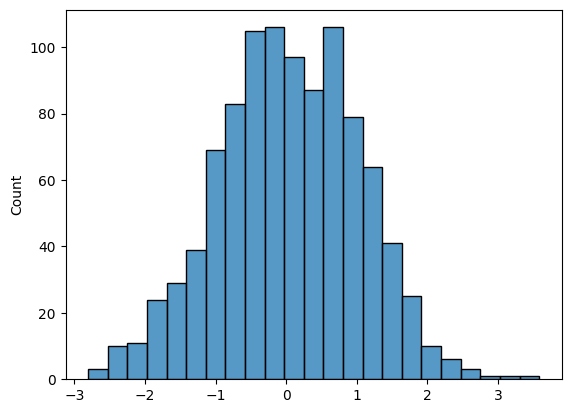

In [29]:
sns.histplot(data)

# What happens here:
# - data → values being plotted
# - histplot → divides data into intervals (bins) and counts frequency

# Default attributes used internally:
# bins = automatic (library decides)
# kde = False (no smooth curve)

plt.show()  # REQUIRED → displays plot

**Histogram + KDE**

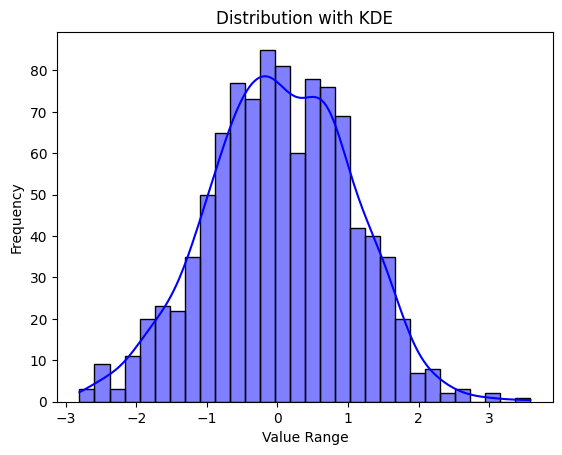

In [30]:
sns.histplot(
    data,          # Input dataset
    bins=30,       # Number of bars (higher = more detail, lower = smoother)
    kde=True,      # Adds smooth density curve
    color='blue',  # Color of bars
    edgecolor='black'  # Border color of bars
)

# Explanation of parameters:
# bins → controls how data is grouped
# kde=True → overlays smooth probability curve
# color → fill color of histogram
# edgecolor → outlines each bar (improves readability)

plt.title("Distribution with KDE")  # Title of graph
plt.xlabel("Value Range")           # X-axis → actual data values
plt.ylabel("Frequency")             # Y-axis → count of values in each bin

plt.show()

**KDE Plot only**

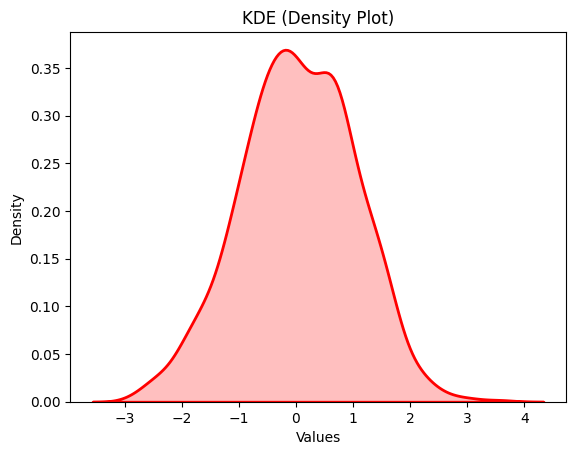

In [31]:
sns.kdeplot(
    data, 
    fill=True,        # Fills area under curve
    color='red', 
    linewidth=2       # Thickness of curve
)

# What KDE represents:
# - It shows probability density instead of count
# - Area under curve = 1 (important concept)

# Parameters:
# fill=True → makes it visually clearer
# linewidth → controls curve thickness

plt.title("KDE (Density Plot)")
plt.xlabel("Values")
plt.ylabel("Density")

plt.show()

### Bins

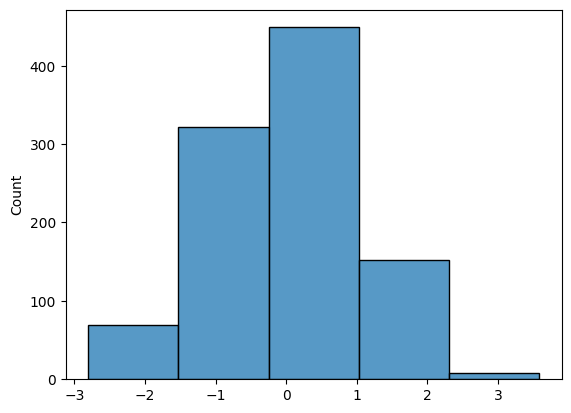

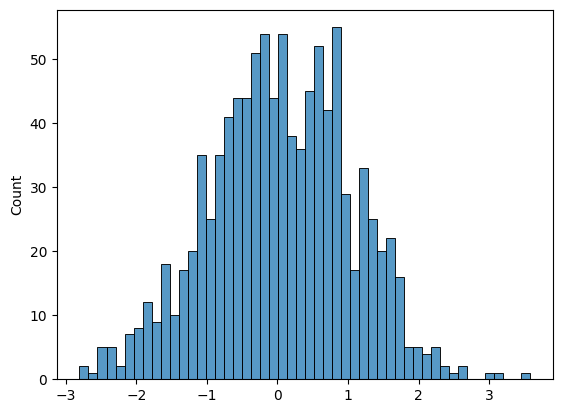

In [32]:
sns.histplot(data, bins=5)   # Very few bins → less detail
plt.show()

sns.histplot(data, bins=50)  # Many bins → more detailed but noisy
plt.show()

# Key idea:
# bins = how we group data

# Example:
# If data range is -3 to 3:
# bins=6 → each bin width = 1
# bins=30 → each bin width = 0.2

# Choosing bins affects interpretation!

### Multiple distributions

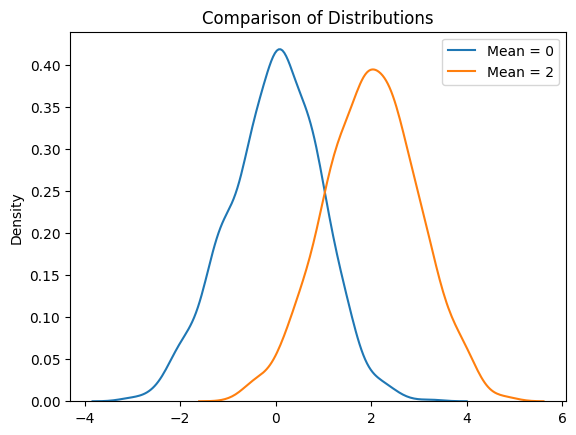

In [33]:
# Create two datasets
data1 = np.random.randn(1000)       # Mean = 0
data2 = np.random.randn(1000) + 2   # Mean shifted to 2

sns.kdeplot(data1, label="Mean = 0")
sns.kdeplot(data2, label="Mean = 2")

# Important:
# +2 shifts entire distribution to the right

plt.legend()  # Uses labels defined above
plt.title("Comparison of Distributions")

plt.show()

### Box Plot

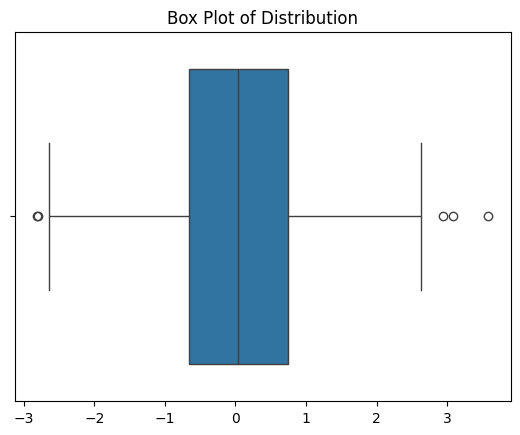

In [34]:
sns.boxplot(x=data)

# What boxplot shows:
# - Median (middle line)
# - Q1 (25th percentile)
# - Q3 (75th percentile)
# - Outliers (points outside range)

# Key terms:
# IQR = Q3 - Q1
# Outliers = values outside (Q1 - 1.5*IQR, Q3 + 1.5*IQR)

plt.title("Box Plot of Distribution")

plt.show()

### Important Attributes

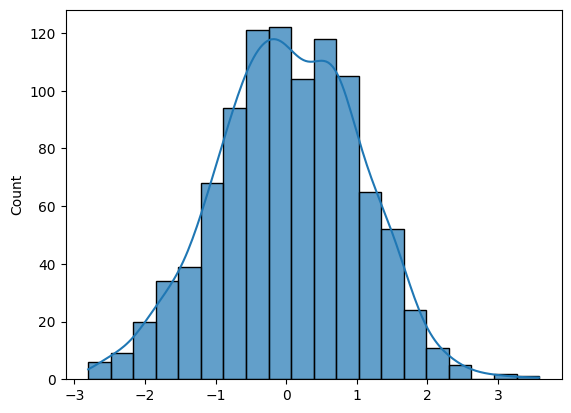

In [35]:
sns.histplot(
    data,
    bins=20,          # Number of bars
    kde=True,         # Add density curve
    stat="count",     # Options: count, frequency, density, probability
    multiple="layer", # Options: layer, stack, dodge (for multiple datasets)
    element="bars",   # bars or step
    alpha=0.7         # Transparency (0 = invisible, 1 = solid)
)

plt.show()

## Real World example and use case

In [36]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [37]:
df['size'].unique()

array([2, 3, 4, 1, 6, 5])

<Axes: xlabel='tip', ylabel='Count'>

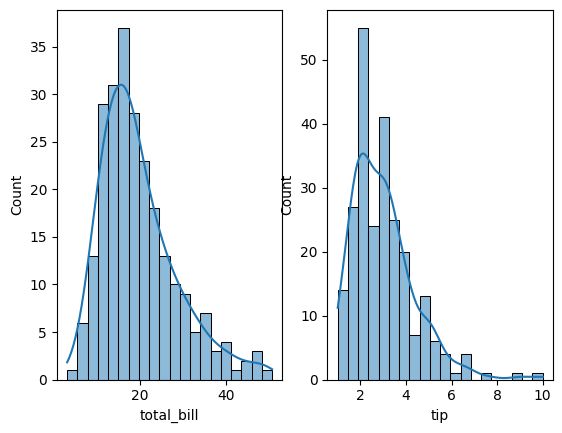

In [38]:
plt.subplot(1,2,1)
sns.histplot(df['total_bill'],bins = 20,kde = True)
plt.subplot(1,2,2)
sns.histplot(df['tip'],bins = 20,kde = True)



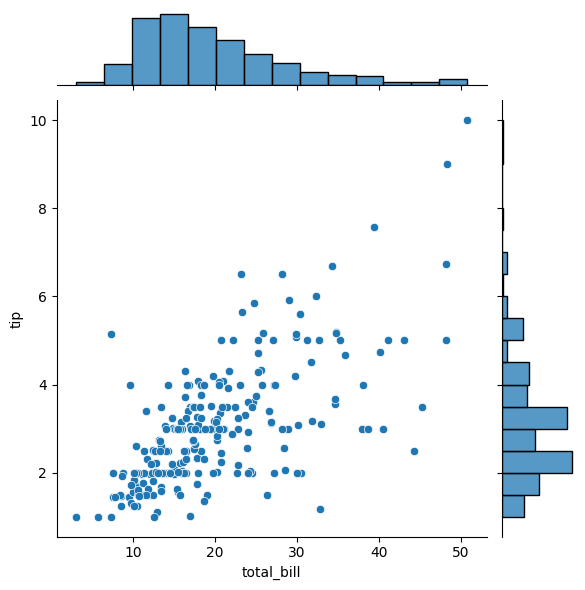

In [39]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df,kind = 'scatter') 
#kind= default is "scatter", "kds","hist","hex","reg","resid"

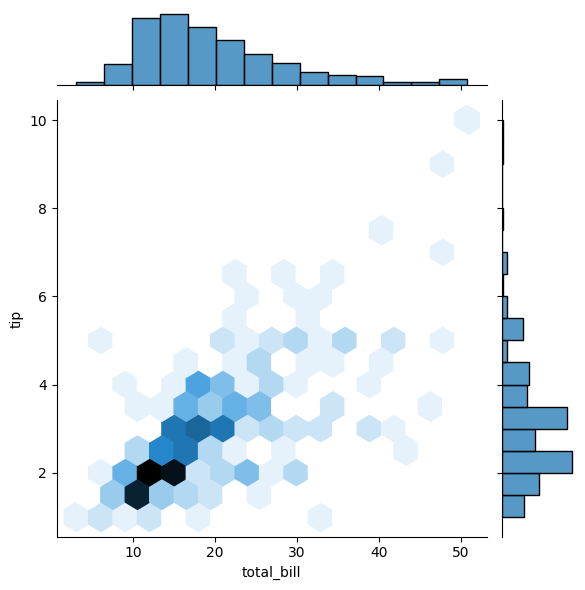

In [40]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df,kind = 'hex')

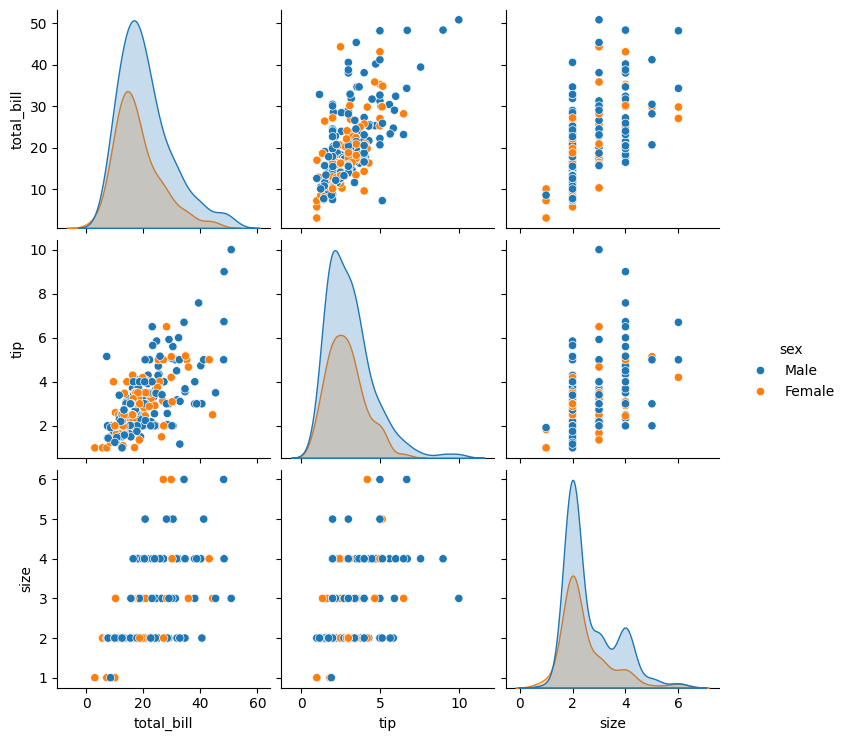

In [41]:
sns.pairplot(df,hue='sex')
#hue: decides on which column have to show the comparision

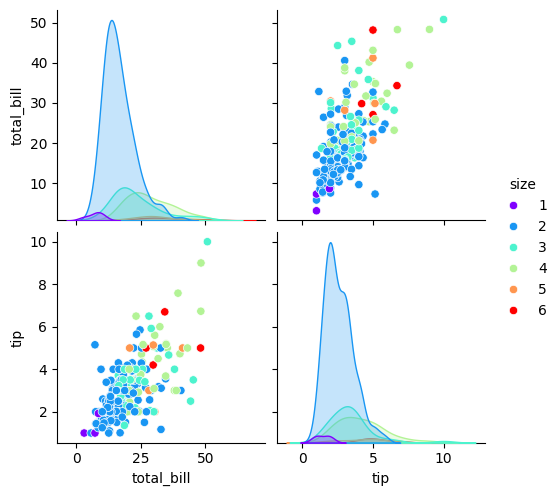

In [42]:
sns.pairplot(df,hue='size',palette='rainbow')


<Axes: xlabel='tip'>

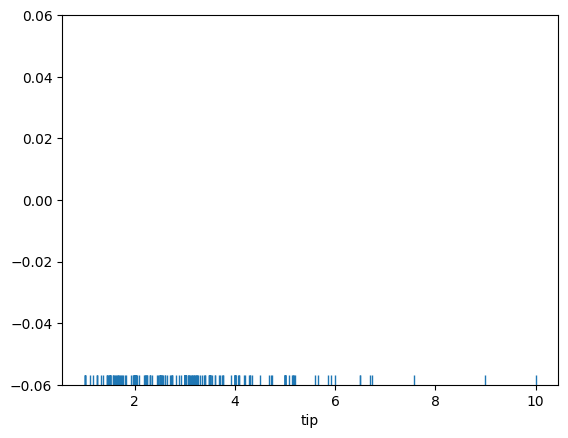

In [43]:
sns.rugplot(df['tip'])